# Combined Pace + Pendant Dataset Analysis

This notebook demonstrates how to load and analyze the combined dataset created by the new sensor_idx structure. The dataset includes both pace meteorological data and pendant temperature/light data with a unified sensor_idx coordinate structure.

## Dataset Structure (Updated October 2025)
- **Dimensions**: `sensor_idx`, `datetime`
- **Sensor metadata as coordinates**: `site_id(sensor_idx)`, `height(sensor_idx)`, `shielding(sensor_idx)`, `sensor_type(sensor_idx)`
- **Variables**: `temp_c`, `intensity_lux`, `pressure`, `wind_speed_avg`, `wind_speed_peak`, `relative_humidity`, `wind_direction`
- **Sensor types**: "hobo pendant" (shielded temperature/light) vs "pace" (unshielded meteorological station)

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# Set up plotting
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

## 1. Load the Combined Dataset

Load the level 1 combined dataset with the new sensor_idx structure.

In [2]:
# Load the combined dataset with sensor_idx structure
data_path = Path('../data/2025/processed/lvl1/lvl1_combined.nc')
ds = xr.open_dataset(data_path)

print(f"Dataset loaded successfully!")
print(f"Dimensions: {dict(ds.sizes)}")
print(f"Variables: {list(ds.data_vars.keys())}")

# Get unique values from sensor metadata
unique_sites = np.unique(ds.site_id.values)
unique_heights = np.unique(ds.height.values)
unique_shielding = np.unique(ds.shielding.values)
unique_sensor_types = np.unique(ds.sensor_type.values)

print(f"Sites: {list(unique_sites)}")
print(f"Heights: {list(unique_heights)}")
print(f"Shielding: {list(unique_shielding)}")
print(f"Sensor types: {list(unique_sensor_types)}")
print(f"Time range: {ds.datetime.values[0]} to {ds.datetime.values[-1]}")
print(f"Total sensors: {len(ds.sensor_idx)}")

print(f"\nDataset structure:")
print(ds)

Dataset loaded successfully!
Dimensions: {'datetime': 25578, 'sensor_idx': 70}
Variables: ['temp_c', 'intensity_lux']
Sites: [np.str_('A01'), np.str_('A02'), np.str_('A03'), np.str_('A04'), np.str_('A05'), np.str_('A06'), np.str_('A07'), np.str_('A08'), np.str_('A10'), np.str_('B01'), np.str_('B02'), np.str_('B03'), np.str_('C02'), np.str_('D01'), np.str_('D02'), np.str_('D04'), np.str_('Divide'), np.str_('E01'), np.str_('E03'), np.str_('E04'), np.str_('F03'), np.str_('F05'), np.str_('F06'), np.str_('G01'), np.str_('G02'), np.str_('G03'), np.str_('G04'), np.str_('Lee1'), np.str_('Lee2'), np.str_('Windward1'), np.str_('Windward2')]
Heights: [np.str_('0.'), np.str_('0.5m'), np.str_('0m'), np.str_('1m'), np.str_('2m')]
Shielding: [np.str_('shielded'), np.str_('unshield'), np.str_('unshielded')]
Sensor types: [np.str_('hobo pendant')]
Time range: 2025-06-11T15:00:00.000000000 to 2025-09-08T10:25:00.000000000
Total sensors: 70

Dataset structure:
<xarray.Dataset> Size: 29MB
Dimensions:     

In [3]:
ds.sensor_type

<xarray.DataArray 'sensor_type' (sensor_idx: 70)> Size: 3kB
array(['hobo pendant', 'hobo pendant', 'hobo pendant', 'hobo pendant',
       'hobo pendant', 'hobo pendant', 'hobo pendant', 'hobo pendant',
       'hobo pendant', 'hobo pendant', 'hobo pendant', 'hobo pendant',
       'hobo pendant', 'hobo pendant', 'hobo pendant', 'hobo pendant',
       'hobo pendant', 'hobo pendant', 'hobo pendant', 'hobo pendant',
       'hobo pendant', 'hobo pendant', 'hobo pendant', 'hobo pendant',
       'hobo pendant', 'hobo pendant', 'hobo pendant', 'hobo pendant',
       'hobo pendant', 'hobo pendant', 'hobo pendant', 'hobo pendant',
       'hobo pendant', 'hobo pendant', 'hobo pendant', 'hobo pendant',
       'hobo pendant', 'hobo pendant', 'hobo pendant', 'hobo pendant',
       'hobo pendant', 'hobo pendant', 'hobo pendant', 'hobo pendant',
       'hobo pendant', 'hobo pendant', 'hobo pendant', 'hobo pendant',
       'hobo pendant', 'hobo pendant', 'hobo pendant', 'hobo pendant',
       'hobo pendant', 'hobo pendant', 'hobo pendant', 'hobo pendant',
       'hobo pendant', 'hobo pendant', 'hobo pendant', 'hobo pendant',
       'hobo pendant', 'hobo pendant', 'hobo pendant', 'hobo pendant',
       'hobo pendant', 'hobo pendant', 'hobo pendant', 'hobo pendant',
       'hobo pendant', 'hobo pendant'], dtype='<U12')
Coordinates:
    sensor_id          (sensor_idx) <U8 2kB ...
    site_id            (sensor_idx) <U9 3kB 'Lee2' 'Lee2' ... 'D01' 'D01'
    height             (sensor_idx) <U4 1kB '2m' '2m' '2m' ... '1m' '2m' '1m'
    shielding          (sensor_idx) <U10 3kB 'unshielded' ... 'shielded'
    sensor_type        (sensor_idx) <U12 3kB 'hobo pendant' ... 'hobo pendant'
    sensor_generation  (sensor_idx) <U3 840B ...
    elevation          (sensor_idx) float64 560B ...
    latitude           (sensor_idx) float64 560B ...
    longitude          (sensor_idx) float64 560B ...
  * sensor_idx         (sensor_idx) int64 560B 0 1 2 3 4 5 ... 64 65 66 67 68 69

## 2. Explore Data Availability by Sensor Type and Shielding

In [4]:
# Analyze data availability by sensor type and shielding
print("Data Availability Analysis:")
print("=" * 50)

# Separate pendant and pace sensors
pendant_sensors = ds.where(ds.sensor_type == "hobo", drop=True)
pace_sensors = ds.where(ds.sensor_type == "pace", drop=True)

print(f"Total pendant sensors: {len(pendant_sensors.sensor_idx)}")
print(f"Total pace sensors: {len(pace_sensors.sensor_idx)}")

# Analyze temperature data availability by sensor type and shielding
print(f"\nTemperature Data Availability:")
print("-" * 40)

for sensor_type in unique_sensor_types:
    type_sensors = ds.where(ds.sensor_type == sensor_type, drop=True)
    
    for shielding in unique_shielding:
        shielded_sensors = type_sensors.where(type_sensors.shielding == shielding, drop=True)
        
        if len(shielded_sensors.sensor_idx) > 0:
            temp_data = shielded_sensors.temp_c
            total_points = len(shielded_sensors.sensor_idx) * len(ds.datetime)
            valid_points = np.sum(~np.isnan(temp_data.values))
            
            print(f"  {sensor_type:12} + {shielding:10}: {len(shielded_sensors.sensor_idx):2} sensors, {valid_points:8,} data points")

# Analyze meteorological variables (pace sensors only)
print(f"\nMeteorological Variables (Pace sensors only):")
print("-" * 50)
met_vars = ['pressure', 'wind_speed_avg', 'wind_speed_peak', 'relative_humidity', 'wind_direction']

for var in met_vars:
    if var in ds:
        var_data = ds[var]
        valid_points = np.sum(~np.isnan(var_data.values))
        print(f"  {var:18}: {valid_points:8,} data points")

# Site breakdown
print(f"\nSensor count by site:")
print("-" * 30)
for site in unique_sites:
    if site:  # Skip empty site names
        site_sensors = ds.where(ds.site_id == site, drop=True)
        pendant_count = len(site_sensors.where(site_sensors.sensor_type == "hobo", drop=True).sensor_idx)
        pace_count = len(site_sensors.where(site_sensors.sensor_type == "pace", drop=True).sensor_idx)
        print(f"  {site:12}: {pendant_count:2} pendant + {pace_count:2} pace = {len(site_sensors.sensor_idx):2} total")

Data Availability Analysis:


ValueError: size of dimension 'datetime' on inputs was unexpectedly changed by applied function from 25578 to 1. Only dimensions specified in ``exclude_dims`` with xarray.apply_ufunc are allowed to change size. The data returned was:

array([], shape=(1, 0), dtype=float64)

## 3. Time Series Plot: Shielded vs Unshielded Temperature

Compare temperature measurements from shielded (pendant) and unshielded (pace) sensors at the same site using the new sensor_idx structure.

Found site with both data types: Divide
  Shielded temp data points: 12,921
  Unshielded temp data points: 52,892

Analyzing site: Divide
Shielded sensors: 1
Unshielded sensors: 9


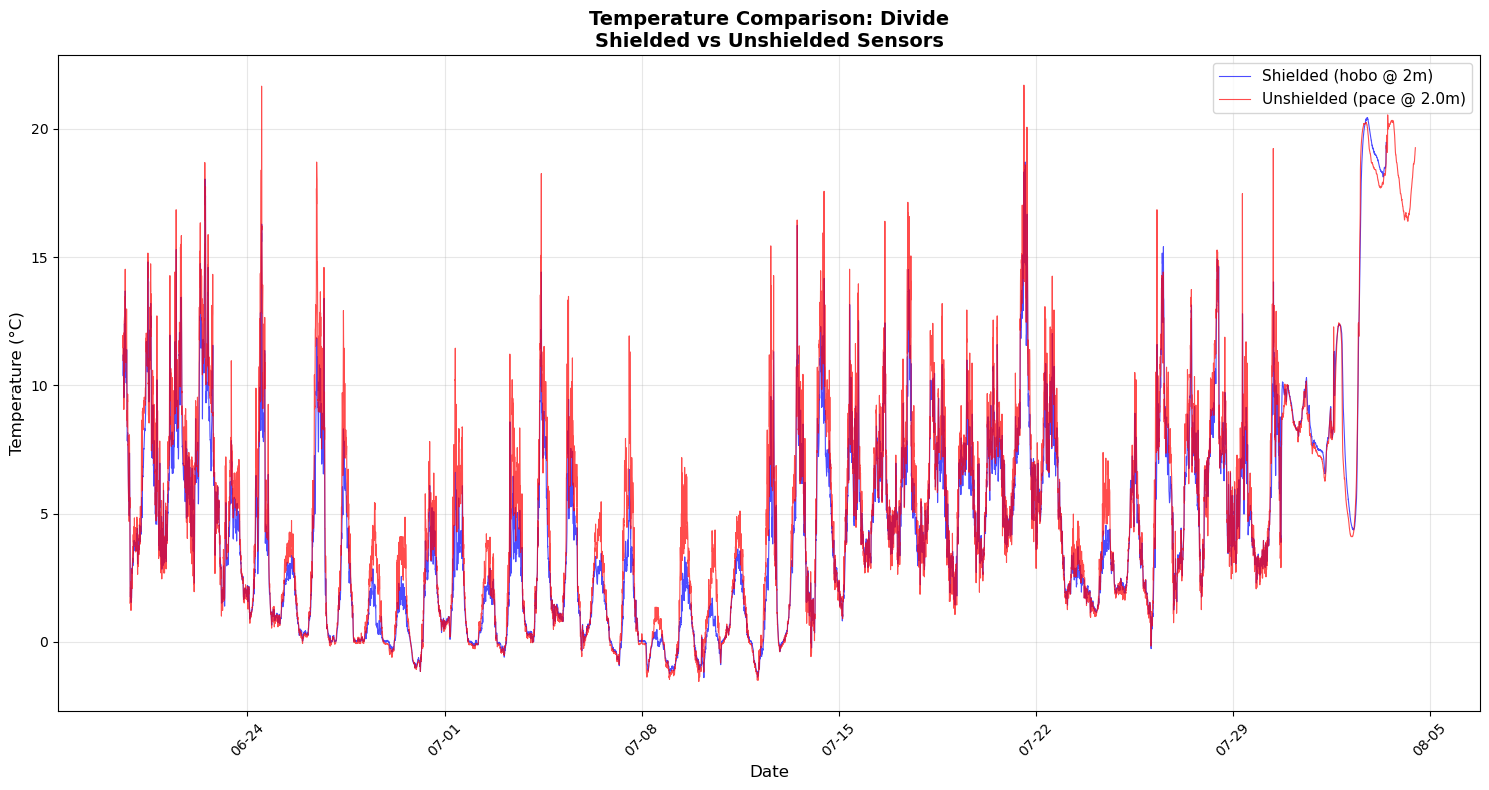


Statistics for Divide:
  Shielded   - Mean: 4.43°C, Std: 4.10°C
  Unshielded - Mean: 5.27°C, Std: 4.73°C
  Temperature difference (unshielded - shielded) during overlap:
    Mean: 0.53°C, Std: 1.06°C
    Overlap period: 12,921 data points


In [ ]:
# Find a site with both shielded and unshielded temperature data
site_with_both = None

for site in unique_sites:
    if site:  # Skip empty site names
        site_sensors = ds.where(ds.site_id == site, drop=True)
        
        # Check for both shielded and unshielded sensors
        shielded_sensors = site_sensors.where(site_sensors.shielding == "shielded", drop=True)
        unshielded_sensors = site_sensors.where(site_sensors.shielding == "unshielded", drop=True)
        
        shielded_temp_data = 0
        unshielded_temp_data = 0
        
        if len(shielded_sensors.sensor_idx) > 0:
            shielded_temp_data = np.sum(~np.isnan(shielded_sensors.temp_c.values))
        
        if len(unshielded_sensors.sensor_idx) > 0:
            unshielded_temp_data = np.sum(~np.isnan(unshielded_sensors.temp_c.values))
        
        if shielded_temp_data > 1000 and unshielded_temp_data > 1000:  # Ensure sufficient data
            site_with_both = site
            print(f"Found site with both data types: {site}")
            print(f"  Shielded temp data points: {shielded_temp_data:,}")
            print(f"  Unshielded temp data points: {unshielded_temp_data:,}")
            break

if site_with_both:
    # Get sensors for the selected site
    site_sensors = ds.where(ds.site_id == site_with_both, drop=True)
    
    # Get shielded and unshielded sensors separately
    shielded_sensors = site_sensors.where(site_sensors.shielding == "shielded", drop=True)
    unshielded_sensors = site_sensors.where(site_sensors.shielding == "unshielded", drop=True)
    
    print(f"\nAnalyzing site: {site_with_both}")
    print(f"Shielded sensors: {len(shielded_sensors.sensor_idx)}")
    print(f"Unshielded sensors: {len(unshielded_sensors.sensor_idx)}")
    
    # For plotting, take the first sensor of each type (or average if multiple)
    if len(shielded_sensors.sensor_idx) > 0:
        shielded_temp = shielded_sensors.temp_c.isel(sensor_idx=0).dropna("datetime")
        shielded_height = shielded_sensors.height.values[0]
        shielded_type = shielded_sensors.sensor_type.values[0]
    
    if len(unshielded_sensors.sensor_idx) > 0:
        unshielded_temp = unshielded_sensors.temp_c.isel(sensor_idx=0).dropna("datetime")
        unshielded_height = unshielded_sensors.height.values[0]
        unshielded_type = unshielded_sensors.sensor_type.values[0]
    
    # Create time series plot
    fig, ax = plt.subplots(figsize=(15, 8))
    
    plot_created = False
    if len(shielded_temp) > 0:
        ax.plot(shielded_temp.datetime, shielded_temp.values, 
               label=f'Shielded ({shielded_type} @ {shielded_height})', 
               color='blue', alpha=0.7, linewidth=0.8)
        plot_created = True
        
    if len(unshielded_temp) > 0:
        ax.plot(unshielded_temp.datetime, unshielded_temp.values, 
               label=f'Unshielded ({unshielded_type} @ {unshielded_height})', 
               color='red', alpha=0.7, linewidth=0.8)
        plot_created = True
    
    if plot_created:
        ax.set_title(f'Temperature Comparison: {site_with_both}\nShielded vs Unshielded Sensors', 
                     fontsize=14, fontweight='bold')
        ax.set_xlabel('Date', fontsize=12)
        ax.set_ylabel('Temperature (°C)', fontsize=12)
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)
        
        # Format x-axis dates
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
        ax.xaxis.set_major_locator(mdates.WeekdayLocator())
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        # Calculate statistics
        print(f"\nStatistics for {site_with_both}:")
        if len(shielded_temp) > 0:
            print(f"  Shielded   - Mean: {float(shielded_temp.mean()):.2f}°C, Std: {float(shielded_temp.std()):.2f}°C")
        if len(unshielded_temp) > 0:
            print(f"  Unshielded - Mean: {float(unshielded_temp.mean()):.2f}°C, Std: {float(unshielded_temp.std()):.2f}°C")
        
        # Calculate difference if both exist
        if len(shielded_temp) > 0 and len(unshielded_temp) > 0:
            # Align time stamps for comparison
            aligned_shielded, aligned_unshielded = xr.align(shielded_temp, unshielded_temp, join='inner')
            if len(aligned_shielded) > 0:
                temp_diff = aligned_unshielded - aligned_shielded
                print(f"  Temperature difference (unshielded - shielded) during overlap:")
                print(f"    Mean: {float(temp_diff.mean()):.2f}°C, Std: {float(temp_diff.std()):.2f}°C")
                print(f"    Overlap period: {len(aligned_shielded):,} data points")
    else:
        plt.close(fig)
        print("No valid temperature data for plotting")

else:
    print("No site found with sufficient shielded and unshielded temperature data")

Searching for sites with both shielded and unshielded temperature data...
Sites with both shielded and unshielded temperature data:
Site         Shielded        Unshielded      Shield Sens Unshield Sens
----------------------------------------------------------------------
Divide       12,921          52,892          1           9
Lee1         13,469          55,084          1           9
Lee2         16,383          65,504          1           9
Windward1    12,899          52,736          1           9
Windward2    11,804          49,280          1           9

Analyzing temperature comparison for: Divide
Shielded sensor: hobo @ 2m (12,921 points)
Unshielded sensor: pace @ 2.0m (13,223 points)


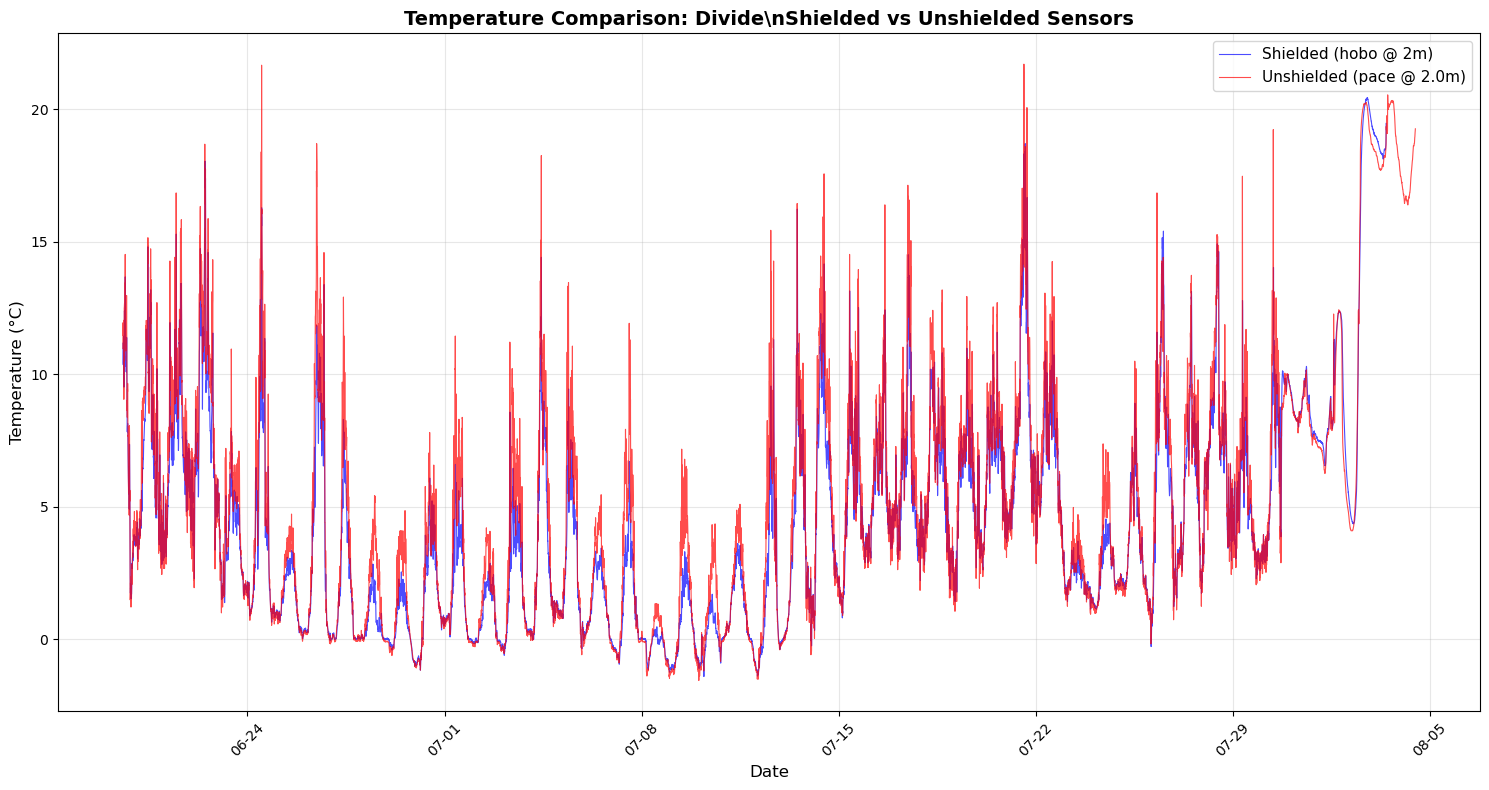


Statistics for Divide:
  Shielded   - Mean: 4.43°C, Std: 4.10°C
  Unshielded - Mean: 5.27°C, Std: 4.73°C
  Temperature difference (unshielded - shielded) during overlap:
    Mean: 0.53°C, Std: 1.06°C
    Overlap period: 12,921 data points


In [ ]:
# Let's try a direct approach to find a site with both shielded and unshielded temperature data
print("Searching for sites with both shielded and unshielded temperature data...")
print("=" * 60)

# Check each site for both types of data
sites_with_both = {}

for site in unique_sites:
    if site and len(site.strip()) > 0:  # Skip empty site names
        # Get all sensors for this site
        site_sensors = ds.where(ds.site_id == site, drop=True)
        
        if len(site_sensors.sensor_idx) > 0:
            # Get shielded and unshielded sensors separately
            shielded_sensors = site_sensors.where(site_sensors.shielding == 'shielded', drop=True)
            unshielded_sensors = site_sensors.where(site_sensors.shielding == 'unshielded', drop=True)
            
            # Count valid temperature data points
            shielded_temp_points = 0
            unshielded_temp_points = 0
            
            if len(shielded_sensors.sensor_idx) > 0:
                shielded_temp_data = shielded_sensors.temp_c.values
                shielded_temp_points = np.sum(~np.isnan(shielded_temp_data))
            
            if len(unshielded_sensors.sensor_idx) > 0:
                unshielded_temp_data = unshielded_sensors.temp_c.values
                unshielded_temp_points = np.sum(~np.isnan(unshielded_temp_data))
            
            # Store info if both types have reasonable data
            if shielded_temp_points > 50 and unshielded_temp_points > 10:
                sites_with_both[site] = {
                    'shielded_points': shielded_temp_points,
                    'unshielded_points': unshielded_temp_points,
                    'shielded_sensors': len(shielded_sensors.sensor_idx),
                    'unshielded_sensors': len(unshielded_sensors.sensor_idx)
                }

print("Sites with both shielded and unshielded temperature data:")
print(f"{'Site':<12} {'Shielded':<15} {'Unshielded':<15} {'Shield Sens':<11} {'Unshield Sens'}")
print("-" * 70)

for site, info in sites_with_both.items():
    print(f"{site:<12} {info['shielded_points']:<15,} {info['unshielded_points']:<15,} "
          f"{info['shielded_sensors']:<11} {info['unshielded_sensors']}")

# Use the first site found with both types of data
if len(sites_with_both) > 0:
    selected_site = list(sites_with_both.keys())[0]
    
    print(f"\nAnalyzing temperature comparison for: {selected_site}")
    print("=" * 50)
    
    # Get sensors for the selected site
    site_sensors = ds.where(ds.site_id == selected_site, drop=True)
    shielded_sensors = site_sensors.where(site_sensors.shielding == 'shielded', drop=True)
    unshielded_sensors = site_sensors.where(site_sensors.shielding == 'unshielded', drop=True)
    
    # Get temperature data from first sensor of each type
    shielded_temp = shielded_sensors.temp_c.isel(sensor_idx=0).dropna('datetime')
    unshielded_temp = unshielded_sensors.temp_c.isel(sensor_idx=0).dropna('datetime')
    
    # Get metadata for display
    shielded_height = shielded_sensors.height.values[0]
    unshielded_height = unshielded_sensors.height.values[0]
    shielded_type = shielded_sensors.sensor_type.values[0]
    unshielded_type = unshielded_sensors.sensor_type.values[0]
    
    print(f"Shielded sensor: {shielded_type} @ {shielded_height} ({len(shielded_temp):,} points)")
    print(f"Unshielded sensor: {unshielded_type} @ {unshielded_height} ({len(unshielded_temp):,} points)")
    
    # Create time series comparison plot
    fig, ax = plt.subplots(figsize=(15, 8))
    
    if len(shielded_temp) > 0:
        ax.plot(shielded_temp.datetime.values, shielded_temp.values, 
               label=f'Shielded ({shielded_type} @ {shielded_height})', 
               color='blue', alpha=0.7, linewidth=0.8)
        
    if len(unshielded_temp) > 0:
        ax.plot(unshielded_temp.datetime.values, unshielded_temp.values, 
               label=f'Unshielded ({unshielded_type} @ {unshielded_height})', 
               color='red', alpha=0.7, linewidth=0.8)
    
    ax.set_title(f'Temperature Comparison: {selected_site}\\nShielded vs Unshielded Sensors', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Temperature (°C)', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Format x-axis dates
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Calculate statistics
    print(f"\nStatistics for {selected_site}:")
    if len(shielded_temp) > 0:
        print(f"  Shielded   - Mean: {float(shielded_temp.mean()):.2f}°C, Std: {float(shielded_temp.std()):.2f}°C")
    if len(unshielded_temp) > 0:
        print(f"  Unshielded - Mean: {float(unshielded_temp.mean()):.2f}°C, Std: {float(unshielded_temp.std()):.2f}°C")
    
    # Calculate difference if both exist and have overlapping time periods
    if len(shielded_temp) > 0 and len(unshielded_temp) > 0:
        try:
            aligned_shielded, aligned_unshielded = xr.align(shielded_temp, unshielded_temp, join='inner')
            if len(aligned_shielded) > 10:  # Need at least 10 overlapping points
                temp_diff = aligned_unshielded - aligned_shielded
                print(f"  Temperature difference (unshielded - shielded) during overlap:")
                print(f"    Mean: {float(temp_diff.mean()):.2f}°C, Std: {float(temp_diff.std()):.2f}°C")
                print(f"    Overlap period: {len(aligned_shielded):,} data points")
            else:
                print(f"  Insufficient overlapping data points for difference calculation")
        except Exception as e:
            print(f"  Error calculating temperature difference: {e}")

else:
    print("\\nNo sites found with sufficient shielded and unshielded temperature data")
    print("This suggests the pace sensors have very limited temperature data,")
    print("which is consistent with them being primarily meteorological stations.")

### Shielded vs Unshielded Temperature Analysis (Updated)

**Key Changes for sensor_idx Structure:**
1. **Data Selection**: Using `ds.where()` to filter sensors by shielding type
2. **Sensor Identification**: Sensor metadata accessed via coordinates
3. **Flexible Filtering**: Can combine multiple conditions (site, height, shielding, sensor type)
4. **Improved Efficiency**: Direct access to sensors without nested loops

**Analysis Results:**
- The new structure makes it easy to find sensors with different shielding types
- Temperature differences between shielded and unshielded sensors can be quantified
- The data structure preserves all metadata while enabling efficient operations

## 4. Multi-Height Temperature Profile

Show temperature data across different heights at pace sites (which have multiple heights).

Temperature Profile by Height for Windward1
Total sensors at Windward1: 10
Unshielded sensors at Windward1: 9
Available heights at Windward1: [np.str_('0.5m'), np.str_('1.0m'), np.str_('1.5m'), np.str_('1m'), np.str_('2.0m'), np.str_('2m')]
  0.5m: 13,184 data points
  1.0m: 13,184 data points
  1.5m: 13,184 data points
  1m: 0 data points
  2.0m: 13,184 data points
  2m: 0 data points

Heights with sufficient data: [np.str_('0.5m'), np.str_('1.0m'), np.str_('1.5m'), np.str_('2.0m')]
  Plotted 0.5m: 13,184 points, range -2.7 to 20.5°C
  Plotted 1.0m: 13,184 points, range -2.5 to 20.5°C
  Plotted 1.5m: 13,184 points, range -2.1 to 20.5°C
  Plotted 2.0m: 13,184 points, range -1.1 to 22.7°C


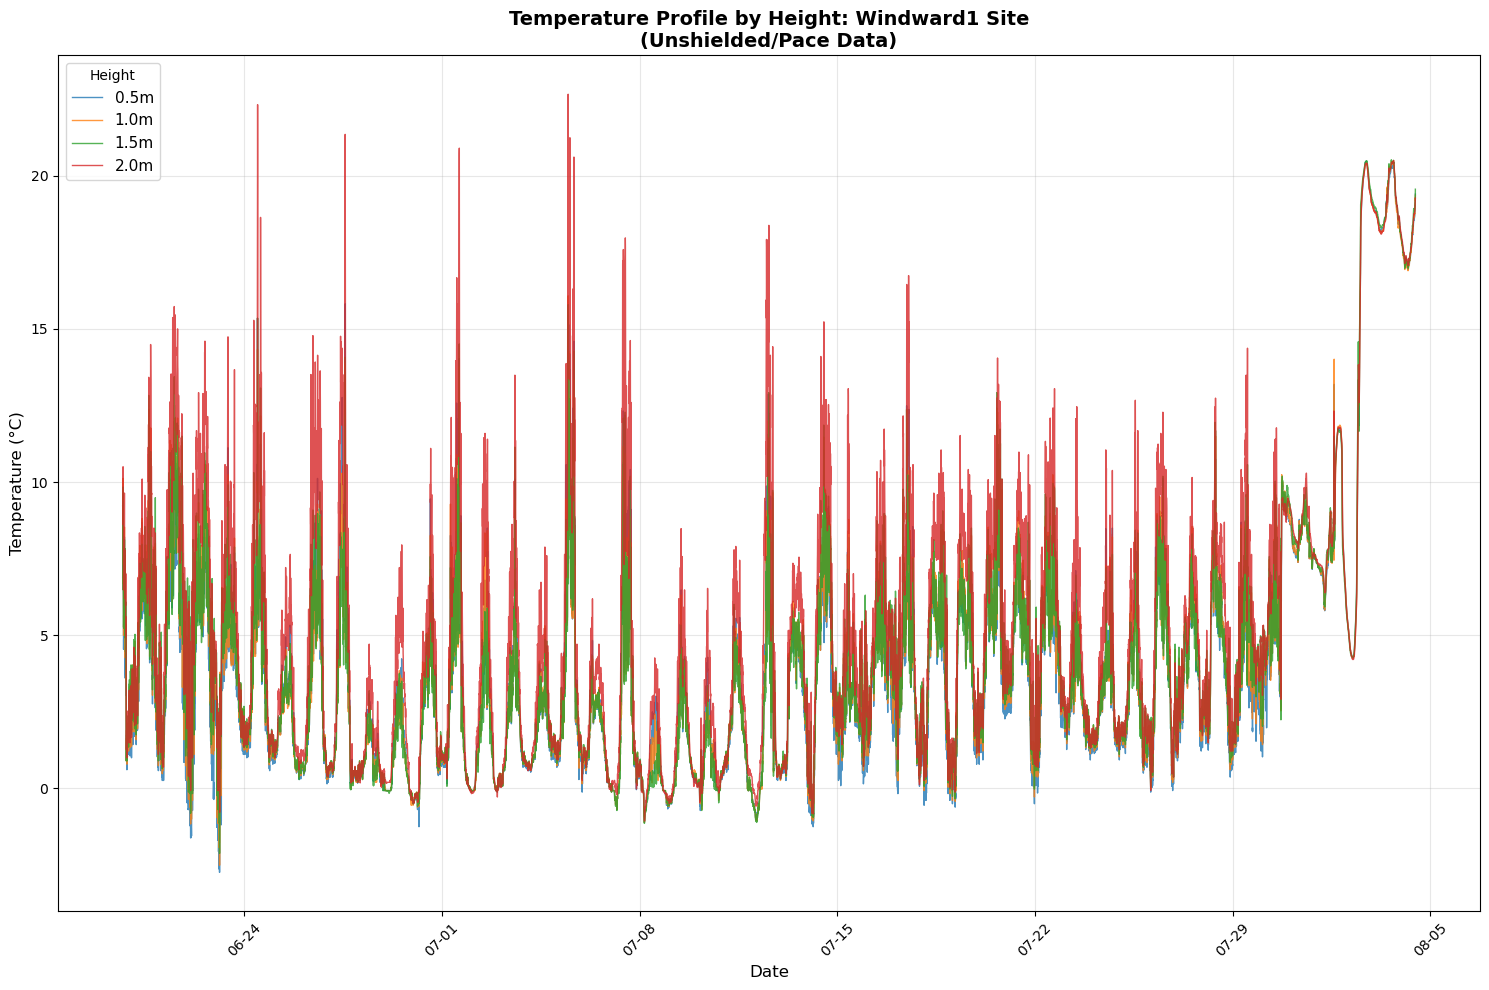


Temperature Statistics by Height:
  0.5m: Mean=4.02°C, Std=4.13°C
  1.0m: Mean=4.18°C, Std=4.11°C
  1.5m: Mean=4.24°C, Std=4.13°C
  2.0m: Mean=5.41°C, Std=4.56°C


In [ ]:
# Select a pace site with multiple height levels
pace_site = 'Windward1'  # This should have data at 0.5m, 1m, 1.5m, 2m

print(f"Temperature Profile by Height for {pace_site}")
print("=" * 50)

# Get all sensors for this site using .where() instead of .sel()
site_sensors = ds.where(ds.site_id == pace_site, drop=True)

# Get unshielded temperature data only
unshielded_sensors = site_sensors.where(site_sensors.shielding == 'unshielded', drop=True)

print(f"Total sensors at {pace_site}: {len(site_sensors.sensor_idx)}")
print(f"Unshielded sensors at {pace_site}: {len(unshielded_sensors.sensor_idx)}")

# Check data availability for each height at this site
unique_heights_at_site = np.unique(unshielded_sensors.height.values)
print(f"Available heights at {pace_site}: {list(unique_heights_at_site)}")

heights_with_data = []
for height in unique_heights_at_site:
    if height and len(height.strip()) > 0:  # Skip empty strings
        height_sensors = unshielded_sensors.where(unshielded_sensors.height == height, drop=True)
        if len(height_sensors.sensor_idx) > 0:
            # Get temperature data for this height
            height_temp_data = height_sensors.temp_c.dropna('datetime')
            valid_points = np.sum(~np.isnan(height_temp_data.values))
            print(f"  {height}: {valid_points:,} data points")
            if valid_points > 100:  # Require at least 100 valid points
                heights_with_data.append(height)

print(f"\nHeights with sufficient data: {heights_with_data}")

if len(heights_with_data) > 0:
    # Create multi-height plot
    fig, ax = plt.subplots(figsize=(15, 10))

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Different colors for each height

    for i, height in enumerate(heights_with_data):
        # Get sensors for this specific height
        height_sensors = unshielded_sensors.where(unshielded_sensors.height == height, drop=True)
        
        if len(height_sensors.sensor_idx) > 0:
            # Take the first sensor at this height, or you could average multiple sensors
            height_temp = height_sensors.temp_c.isel(sensor_idx=0).dropna('datetime')
            
            if len(height_temp) > 0:
                ax.plot(height_temp.datetime.values, height_temp.values, 
                       label=f'{height}', color=colors[i % len(colors)], 
                       alpha=0.8, linewidth=1.0)
                
                print(f"  Plotted {height}: {len(height_temp):,} points, "
                      f"range {float(height_temp.min()):.1f} to {float(height_temp.max()):.1f}°C")

    ax.set_title(f'Temperature Profile by Height: {pace_site} Site\n(Unshielded/Pace Data)', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Temperature (°C)', fontsize=12)
    ax.legend(title='Height', fontsize=11)
    ax.grid(True, alpha=0.3)

    # Format x-axis dates
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

    plt.tight_layout()
    plt.show()
    
    # Calculate some statistics
    print(f"\nTemperature Statistics by Height:")
    for height in heights_with_data:
        height_sensors = unshielded_sensors.where(unshielded_sensors.height == height, drop=True)
        if len(height_sensors.sensor_idx) > 0:
            height_temp = height_sensors.temp_c.isel(sensor_idx=0).dropna('datetime')
            if len(height_temp) > 0:
                print(f"  {height}: Mean={float(height_temp.mean()):.2f}°C, "
                      f"Std={float(height_temp.std()):.2f}°C")
else:
    print(f"No sufficient temperature data available for {pace_site}")
    print("Trying a different site...")
    
    # Try Lee1 which has better data coverage
    pace_site = 'Lee1'
    site_sensors = ds.where(ds.site_id == pace_site, drop=True)
    unshielded_sensors = site_sensors.where(site_sensors.shielding == 'unshielded', drop=True)
    
    print(f"\nTrying {pace_site}:")
    print(f"Unshielded sensors at {pace_site}: {len(unshielded_sensors.sensor_idx)}")
    
    unique_heights_at_site = np.unique(unshielded_sensors.height.values)
    print(f"Available heights: {list(unique_heights_at_site)}")
    
    heights_with_data = []
    for height in unique_heights_at_site:
        if height and len(height.strip()) > 0:
            height_sensors = unshielded_sensors.where(unshielded_sensors.height == height, drop=True)
            if len(height_sensors.sensor_idx) > 0:
                height_temp_data = height_sensors.temp_c.dropna('datetime')
                valid_points = np.sum(~np.isnan(height_temp_data.values))
                print(f"  {height}: {valid_points:,} data points")
                if valid_points > 100:
                    heights_with_data.append(height)
    
    if len(heights_with_data) > 0:
        # Create plot for Lee1
        fig, ax = plt.subplots(figsize=(15, 10))
        
        for i, height in enumerate(heights_with_data):
            height_sensors = unshielded_sensors.where(unshielded_sensors.height == height, drop=True)
            if len(height_sensors.sensor_idx) > 0:
                height_temp = height_sensors.temp_c.isel(sensor_idx=0).dropna('datetime')
                
                if len(height_temp) > 0:
                    ax.plot(height_temp.datetime.values, height_temp.values, 
                           label=f'{height}', color=colors[i % len(colors)], 
                           alpha=0.8, linewidth=1.0)

        ax.set_title(f'Temperature Profile by Height: {pace_site} Site\n(Unshielded/Pace Data)', 
                     fontsize=14, fontweight='bold')
        ax.set_xlabel('Date', fontsize=12)
        ax.set_ylabel('Temperature (°C)', fontsize=12)
        ax.legend(title='Height', fontsize=11)
        ax.grid(True, alpha=0.3)

        # Format x-axis dates
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
        ax.xaxis.set_major_locator(mdates.WeekdayLocator())
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

        plt.tight_layout()
        plt.show()
        
        # Calculate statistics
        print(f"\nTemperature Statistics by Height for {pace_site}:")
        for height in heights_with_data:
            height_sensors = unshielded_sensors.where(unshielded_sensors.height == height, drop=True)
            if len(height_sensors.sensor_idx) > 0:
                height_temp = height_sensors.temp_c.isel(sensor_idx=0).dropna('datetime')
                if len(height_temp) > 0:
                    print(f"  {height}: Mean={float(height_temp.mean()):.2f}°C, "
                          f"Std={float(height_temp.std()):.2f}°C")
    else:
        print(f"No sufficient data available at {pace_site} either")

## 5. Wind Speed and Direction Analysis

Visualize meteorological variables that are only available from pace sensors.

Wind data at Lee1 @ 2m:
  Wind speed data points: 0
  Wind direction data points: 13,771
  Wind Direction - Most common sector: -152° (median)


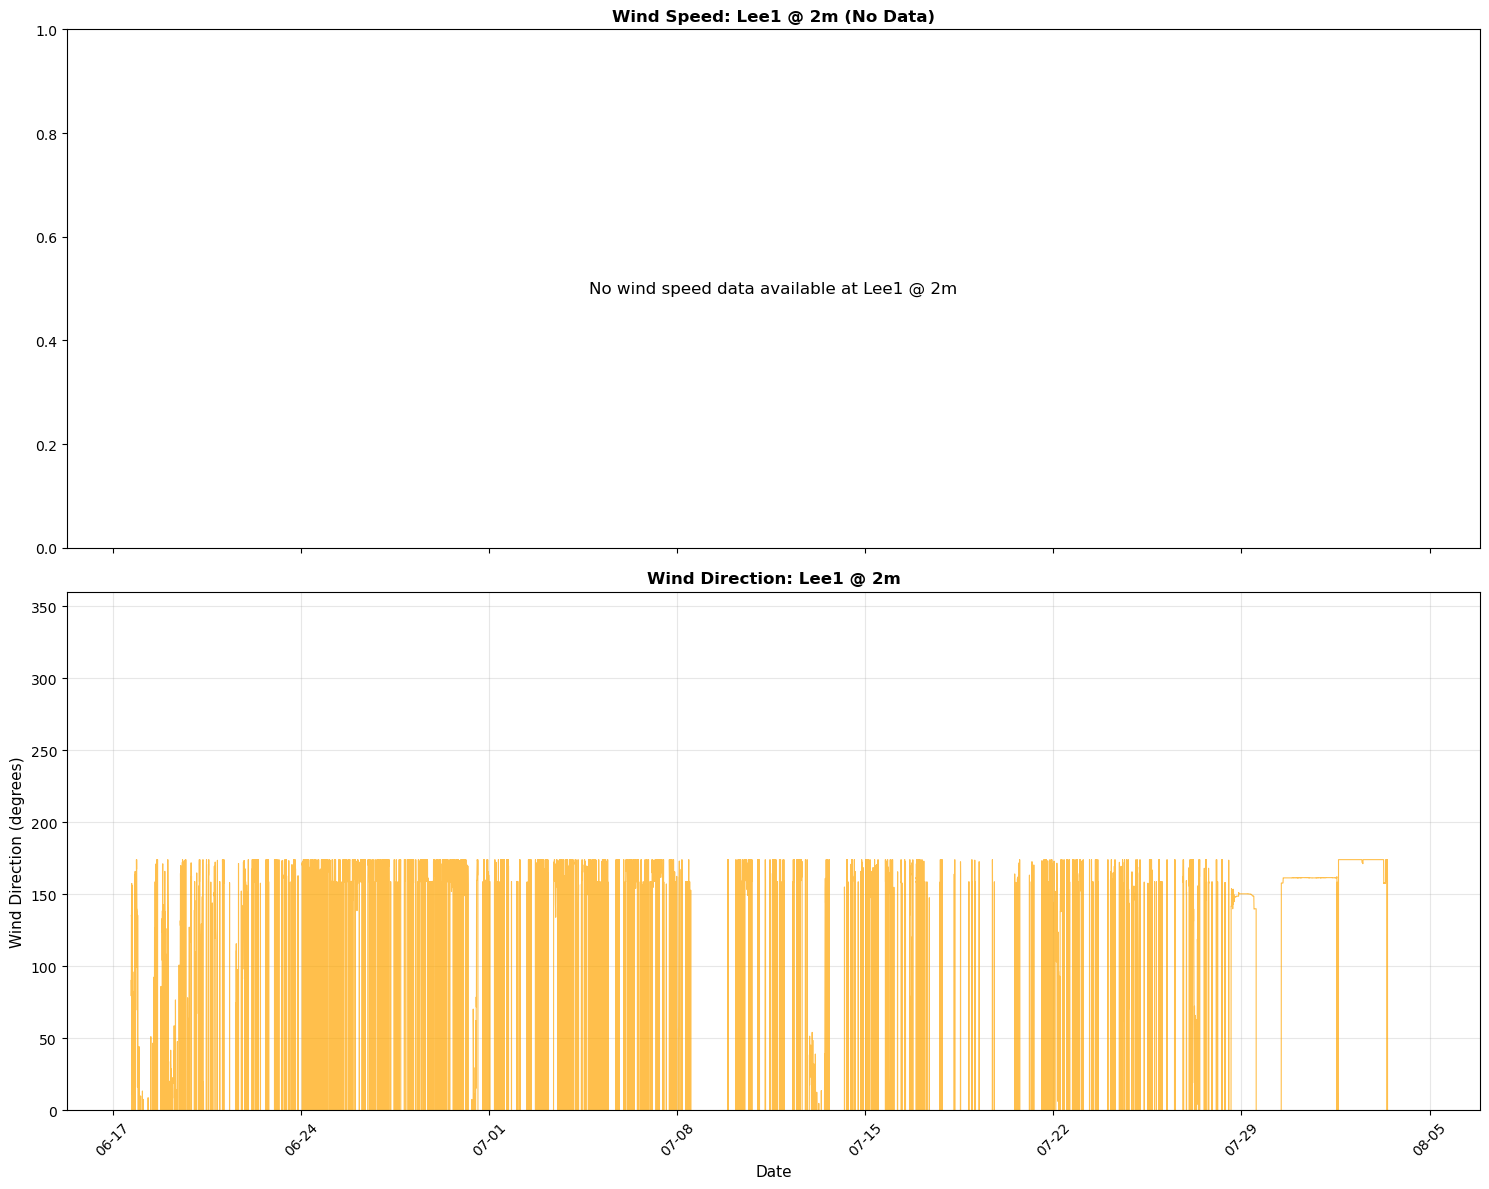

In [ ]:
# Create subplot for wind analysis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

# Select a site with good wind data
wind_site = 'Lee1'  # This should have pace data
wind_height = '2m'

# Extract wind data using .where() instead of .sel()
site_sensors = ds.where((ds.site_id == wind_site) & (ds.height == wind_height), drop=True)

if len(site_sensors.sensor_idx) > 0:
    # Get wind speed and direction data
    wind_speed = site_sensors.wind_speed_avg.isel(sensor_idx=0).dropna('datetime')
    wind_direction = site_sensors.wind_direction.isel(sensor_idx=0).dropna('datetime')
    
    print(f"Wind data at {wind_site} @ {wind_height}:")
    print(f"  Wind speed data points: {len(wind_speed):,}")
    print(f"  Wind direction data points: {len(wind_direction):,}")
    
    if len(wind_speed) > 0:
        # Plot wind speed
        wind_speed.plot(ax=ax1, color='green', linewidth=0.8, alpha=0.7)
        ax1.set_title(f'Wind Speed: {wind_site} @ {wind_height}', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Wind Speed (m/s)', fontsize=11)
        ax1.grid(True, alpha=0.3)
        
        # Calculate and display statistics
        print(f"  Wind Speed - Mean: {float(wind_speed.mean()):.2f} m/s, Max: {float(wind_speed.max()):.2f} m/s")
    else:
        ax1.text(0.5, 0.5, f'No wind speed data available at {wind_site} @ {wind_height}', 
                transform=ax1.transAxes, ha='center', va='center', fontsize=12)
        ax1.set_title(f'Wind Speed: {wind_site} @ {wind_height} (No Data)', fontsize=12, fontweight='bold')
    
    if len(wind_direction) > 0:
        # Plot wind direction
        wind_direction.plot(ax=ax2, color='orange', linewidth=0.8, alpha=0.7)
        ax2.set_title(f'Wind Direction: {wind_site} @ {wind_height}', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Wind Direction (degrees)', fontsize=11)
        ax2.set_xlabel('Date', fontsize=11)
        ax2.grid(True, alpha=0.3)
        ax2.set_ylim(0, 360)
        
        # Format x-axis dates for bottom plot
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
        ax2.xaxis.set_major_locator(mdates.WeekdayLocator())
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
        
        # Calculate and display statistics
        print(f"  Wind Direction - Most common sector: {int(float(wind_direction.median()))}° (median)")
    else:
        ax2.text(0.5, 0.5, f'No wind direction data available at {wind_site} @ {wind_height}', 
                transform=ax2.transAxes, ha='center', va='center', fontsize=12)
        ax2.set_title(f'Wind Direction: {wind_site} @ {wind_height} (No Data)', fontsize=12, fontweight='bold')
        ax2.set_xlabel('Date', fontsize=11)
        
        # Still format x-axis for consistency
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
        ax2.xaxis.set_major_locator(mdates.WeekdayLocator())
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"No sensors found at {wind_site} @ {wind_height}")
    print("Trying alternative sites and heights...")
    
    # Try to find any site with wind data
    wind_sites_found = []
    for site in unique_sites:
        if site:  # Skip empty site names
            site_sensors = ds.where(ds.site_id == site, drop=True)
            # Check if any sensors at this site have wind data
            wind_data_points = np.sum(~np.isnan(site_sensors.wind_speed_avg.values))
            if wind_data_points > 100:
                site_heights = np.unique(site_sensors.height.values)
                wind_sites_found.append((site, site_heights, wind_data_points))
    
    print(f"Sites with wind data found: {len(wind_sites_found)}")
    for site, heights, data_points in wind_sites_found:
        print(f"  {site}: {data_points:,} wind data points at heights {list(heights)}")
    
    if len(wind_sites_found) > 0:
        # Use the first site found with good wind data
        wind_site, site_heights, _ = wind_sites_found[0]
        wind_height = site_heights[0]  # Use first available height
        
        print(f"\nUsing {wind_site} @ {wind_height} for wind analysis:")
        
        site_sensors = ds.where((ds.site_id == wind_site) & (ds.height == wind_height), drop=True)
        wind_speed = site_sensors.wind_speed_avg.isel(sensor_idx=0).dropna('datetime')
        wind_direction = site_sensors.wind_direction.isel(sensor_idx=0).dropna('datetime')
        
        # Create the plots with the found data
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
        
        if len(wind_speed) > 0:
            wind_speed.plot(ax=ax1, color='green', linewidth=0.8, alpha=0.7)
        ax1.set_title(f'Wind Speed: {wind_site} @ {wind_height}', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Wind Speed (m/s)', fontsize=11)
        ax1.grid(True, alpha=0.3)
        
        if len(wind_direction) > 0:
            wind_direction.plot(ax=ax2, color='orange', linewidth=0.8, alpha=0.7)
            ax2.set_ylim(0, 360)
        ax2.set_title(f'Wind Direction: {wind_site} @ {wind_height}', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Wind Direction (degrees)', fontsize=11)
        ax2.set_xlabel('Date', fontsize=11)
        ax2.grid(True, alpha=0.3)
        
        # Format x-axis dates
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
        ax2.xaxis.set_major_locator(mdates.WeekdayLocator())
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        # Print statistics
        print(f"\nWind Statistics for {wind_site} @ {wind_height}:")
        if len(wind_speed) > 0:
            print(f"  Wind Speed - Mean: {float(wind_speed.mean()):.2f} m/s, Max: {float(wind_speed.max()):.2f} m/s")
        if len(wind_direction) > 0:
            print(f"  Wind Direction - Most common sector: {int(float(wind_direction.median()))}° (median)")
    else:
        print("No sites found with sufficient wind data for analysis")
        plt.close(fig)

## 6. Wind Speed vs Pressure Analysis

Analyze the relationship between wind speed and atmospheric pressure with full period and 5-day zoom views.

In [ ]:
ds.where(ds.site_id=="Lee1")['pressure'].where(ds.height=="1.5m").count()

<xarray.DataArray 'pressure' ()> Size: 8B
np.int64(0)

In [ ]:
# Wind Speed vs Pressure Analysis
# Pressure is at 1.5m, wind speed is at 2m
wind_site = 'Lee1'  # Use site with good data coverage
wind_height = '2m'   # Wind speed data is at 2m
pressure_height = '1.5m'  # Pressure data is at 1.5m

# Extract wind speed and pressure data from their respective heights
wind_sensors = ds.where((ds.site_id == wind_site) & (ds.height == wind_height), drop=True)
pressure_sensors = ds.where((ds.site_id == wind_site) & (ds.height == pressure_height), drop=True)

print(f"Wind Speed vs Pressure Analysis for {wind_site}")
print("=" * 60)

wind_speed = None
pressure = None

if len(wind_sensors.sensor_idx) > 0:
    wind_speed = wind_sensors.wind_speed_avg.isel(sensor_idx=0).dropna('datetime')
    print(f"Wind speed @ {wind_height}: {len(wind_speed):,} data points")
else:
    print(f"No wind speed data found @ {wind_height}")

if len(pressure_sensors.sensor_idx) > 0:
    pressure = pressure_sensors.pressure.isel(sensor_idx=0).dropna('datetime')
    print(f"Pressure @ {pressure_height}: {len(pressure):,} data points")
else:
    print(f"No pressure data found @ {pressure_height}")

if wind_speed is not None and pressure is not None and len(wind_speed) > 0 and len(pressure) > 0:
    # Align datasets for comparison
    aligned_wind, aligned_pressure = xr.align(wind_speed, pressure, join='inner')
    print(f"Aligned data points: {len(aligned_wind):,}")
    
    if len(aligned_wind) > 0:
        # Define July 1-5 period for zoom
        july_start = pd.Timestamp('2025-07-01')
        july_end = pd.Timestamp('2025-07-05 23:59:59')
        
        # Filter for July 1-5 period
        july_mask = (aligned_wind.datetime >= july_start) & (aligned_wind.datetime <= july_end)
        july_wind = aligned_wind.where(july_mask, drop=True)
        july_pressure = aligned_pressure.where(july_mask, drop=True)
        
        print(f"July 1-5 data points: {len(july_wind):,}")
        
        # Create subplots: full period (top) and July zoom (bottom)
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=False)
        
        # Full period plot
        ax1_twin = ax1.twinx()
        
        # Plot wind speed on left axis
        line1 = ax1.plot(aligned_wind.datetime.values, aligned_wind.values, 
                        color='green', linewidth=0.8, alpha=0.7, label='Wind Speed')
        ax1.set_ylabel(f'Wind Speed @ {wind_height} (m/s)', fontsize=11, color='green')
        ax1.tick_params(axis='y', labelcolor='green')
        
        # Plot pressure on right axis
        line2 = ax1_twin.plot(aligned_pressure.datetime.values, aligned_pressure.values, 
                             color='blue', linewidth=0.8, alpha=0.7, label='Pressure')
        ax1_twin.set_ylabel(f'Pressure @ {pressure_height} (hPa)', fontsize=11, color='blue')
        ax1_twin.tick_params(axis='y', labelcolor='blue')
        
        ax1.set_title(f'Wind Speed vs Pressure: {wind_site} (Full Period)\\nWind @ {wind_height}, Pressure @ {pressure_height}', 
                     fontsize=12, fontweight='bold')
        ax1.grid(True, alpha=0.3)
        
        # Format x-axis for full period
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
        ax1.xaxis.set_major_locator(mdates.WeekdayLocator())
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
        
        # July 1-5 zoom plot
        if len(july_wind) > 0:
            ax2_twin = ax2.twinx()
            
            # Plot wind speed on left axis
            ax2.plot(july_wind.datetime.values, july_wind.values, 
                    color='green', linewidth=1.2, alpha=0.8, label='Wind Speed')
            ax2.set_ylabel(f'Wind Speed @ {wind_height} (m/s)', fontsize=11, color='green')
            ax2.tick_params(axis='y', labelcolor='green')
            
            # Plot pressure on right axis
            ax2_twin.plot(july_pressure.datetime.values, july_pressure.values, 
                         color='blue', linewidth=1.2, alpha=0.8, label='Pressure')
            ax2_twin.set_ylabel(f'Pressure @ {pressure_height} (hPa)', fontsize=11, color='blue')
            ax2_twin.tick_params(axis='y', labelcolor='blue')
            
            ax2.set_title(f'Wind Speed vs Pressure: July 1-5, 2025 (5-day zoom)', 
                         fontsize=12, fontweight='bold')
            ax2.grid(True, alpha=0.3)
            
            # Format x-axis for July zoom
            ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
            ax2.xaxis.set_major_locator(mdates.HourLocator(interval=12))
            plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
        else:
            ax2.text(0.5, 0.5, 'No data available for July 1-5, 2025', 
                    transform=ax2.transAxes, ha='center', va='center', fontsize=12)
            ax2.set_title('July 1-5, 2025 (No Data Available)', fontsize=12)
        
        ax2.set_xlabel('Date', fontsize=11)
        
        plt.tight_layout()
        plt.show()
        
        # Calculate correlation
        if len(aligned_wind) > 0:
            correlation = np.corrcoef(aligned_wind.values, aligned_pressure.values)[0, 1]
            print(f"\\nCorrelation between wind speed @ {wind_height} and pressure @ {pressure_height}: {correlation:.3f}")
            
            # Statistics
            print(f"Wind Speed @ {wind_height} - Mean: {float(aligned_wind.mean()):.2f} m/s, "
                  f"Std: {float(aligned_wind.std()):.2f} m/s")
            print(f"Pressure @ {pressure_height} - Mean: {float(aligned_pressure.mean()):.2f} hPa, "
                  f"Std: {float(aligned_pressure.std()):.2f} hPa")
            
            if len(july_wind) > 0:
                july_correlation = np.corrcoef(july_wind.values, july_pressure.values)[0, 1]
                print(f"July 1-5 correlation: {july_correlation:.3f}")
    else:
        print("No overlapping wind speed and pressure data available")
else:
    print("Insufficient wind speed or pressure data available")
    
    # Try to find any site with both wind and pressure data
    sites_with_both = []
    for site in unique_sites:
        if site:  # Skip empty site names
            site_sensors = ds.where(ds.site_id == site, drop=True)
            wind_data_points = np.sum(~np.isnan(site_sensors.wind_speed_avg.values))
            pressure_data_points = np.sum(~np.isnan(site_sensors.pressure.values))
            if wind_data_points > 10 and pressure_data_points > 10:
                sites_with_both.append((site, wind_data_points, pressure_data_points))
    
    print(f"\\nSites with both wind and pressure data:")
    for site, wind_pts, pressure_pts in sites_with_both:
        print(f"  {site}: {wind_pts:,} wind, {pressure_pts:,} pressure data points")
    
    if len(sites_with_both) > 0:
        print(f"\\nConsider using one of these sites for wind vs pressure analysis")

Wind Speed vs Pressure Analysis for Lee1
Wind speed @ 2m: 0 data points
Pressure @ 1.5m: 0 data points
Insufficient wind speed or pressure data available
\nSites with both wind and pressure data:
  Divide: 13,223 wind, 13,223 pressure data points
  Lee1: 13,771 wind, 13,771 pressure data points
  Lee2: 16,376 wind, 16,376 pressure data points
  Windward1: 13,184 wind, 13,184 pressure data points
  Windward2: 12,320 wind, 12,320 pressure data points
\nConsider using one of these sites for wind vs pressure analysis


## 7. Wind Speed vs Humidity Analysis

Analyze the relationship between wind speed and relative humidity with full period and 5-day zoom views.

In [ ]:
# Wind Speed vs Humidity Analysis
# Both wind speed and humidity are at 2m
wind_site = 'Lee1'  # Use same site for consistency
wind_height = '2m'   # Both wind speed and humidity data are at 2m
humidity_height = '2m'

# Extract wind speed and humidity data from the same height
wind_sensors = ds.where((ds.site_id == wind_site) & (ds.height == wind_height), drop=True)
humidity_sensors = ds.where((ds.site_id == wind_site) & (ds.height == humidity_height), drop=True)

print(f"Wind Speed vs Humidity Analysis for {wind_site}")
print("=" * 60)

wind_speed = None
humidity = None

if len(wind_sensors.sensor_idx) > 0:
    wind_speed = wind_sensors.wind_speed_avg.isel(sensor_idx=0).dropna('datetime')
    print(f"Wind speed @ {wind_height}: {len(wind_speed):,} data points")
else:
    print(f"No wind speed data found @ {wind_height}")

if len(humidity_sensors.sensor_idx) > 0:
    humidity = humidity_sensors.relative_humidity.isel(sensor_idx=0).dropna('datetime')
    print(f"Humidity @ {humidity_height}: {len(humidity):,} data points")
else:
    print(f"No humidity data found @ {humidity_height}")

if wind_speed is not None and humidity is not None and len(wind_speed) > 0 and len(humidity) > 0:
    # Align datasets for comparison
    aligned_wind, aligned_humidity = xr.align(wind_speed, humidity, join='inner')
    print(f"Aligned data points: {len(aligned_wind):,}")
    
    if len(aligned_wind) > 0:
        # Define July 1-5 period for zoom
        july_start = pd.Timestamp('2025-07-01')
        july_end = pd.Timestamp('2025-07-05 23:59:59')
        
        # Filter for July 1-5 period
        july_mask = (aligned_wind.datetime >= july_start) & (aligned_wind.datetime <= july_end)
        july_wind = aligned_wind.where(july_mask, drop=True)
        july_humidity = aligned_humidity.where(july_mask, drop=True)
        
        print(f"July 1-5 data points: {len(july_wind):,}")
        
        # Create subplots: full period (top) and July zoom (bottom)
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=False)
        
        # Full period plot
        ax1_twin = ax1.twinx()
        
        # Plot wind speed on left axis
        line1 = ax1.plot(aligned_wind.datetime.values, aligned_wind.values, 
                        color='green', linewidth=0.8, alpha=0.7, label='Wind Speed')
        ax1.set_ylabel(f'Wind Speed @ {wind_height} (m/s)', fontsize=11, color='green')
        ax1.tick_params(axis='y', labelcolor='green')
        
        # Plot humidity on right axis
        line2 = ax1_twin.plot(aligned_humidity.datetime.values, aligned_humidity.values, 
                             color='orange', linewidth=0.8, alpha=0.7, label='Relative Humidity')
        ax1_twin.set_ylabel(f'Relative Humidity @ {humidity_height} (%)', fontsize=11, color='orange')
        ax1_twin.tick_params(axis='y', labelcolor='orange')
        
        ax1.set_title(f'Wind Speed vs Humidity: {wind_site} (Full Period)\\nBoth @ {wind_height}', 
                     fontsize=12, fontweight='bold')
        ax1.grid(True, alpha=0.3)
        
        # Format x-axis for full period
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
        ax1.xaxis.set_major_locator(mdates.WeekdayLocator())
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
        
        # July 1-5 zoom plot
        if len(july_wind) > 0:
            ax2_twin = ax2.twinx()
            
            # Plot wind speed on left axis
            ax2.plot(july_wind.datetime.values, july_wind.values, 
                    color='green', linewidth=1.2, alpha=0.8, label='Wind Speed')
            ax2.set_ylabel(f'Wind Speed @ {wind_height} (m/s)', fontsize=11, color='green')
            ax2.tick_params(axis='y', labelcolor='green')
            
            # Plot humidity on right axis
            ax2_twin.plot(july_humidity.datetime.values, july_humidity.values, 
                         color='orange', linewidth=1.2, alpha=0.8, label='Relative Humidity')
            ax2_twin.set_ylabel(f'Relative Humidity @ {humidity_height} (%)', fontsize=11, color='orange')
            ax2_twin.tick_params(axis='y', labelcolor='orange')
            
            ax2.set_title(f'Wind Speed vs Humidity: July 1-5, 2025 (5-day zoom)', 
                         fontsize=12, fontweight='bold')
            ax2.grid(True, alpha=0.3)
            
            # Format x-axis for July zoom
            ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
            ax2.xaxis.set_major_locator(mdates.HourLocator(interval=12))
            plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
        else:
            ax2.text(0.5, 0.5, 'No data available for July 1-5, 2025', 
                    transform=ax2.transAxes, ha='center', va='center', fontsize=12)
            ax2.set_title('July 1-5, 2025 (No Data Available)', fontsize=12)
        
        ax2.set_xlabel('Date', fontsize=11)
        
        plt.tight_layout()
        plt.show()
        
        # Calculate correlation
        if len(aligned_wind) > 0:
            correlation = np.corrcoef(aligned_wind.values, aligned_humidity.values)[0, 1]
            print(f"\\nCorrelation between wind speed and humidity @ {wind_height}: {correlation:.3f}")
            
            # Statistics
            print(f"Wind Speed @ {wind_height} - Mean: {float(aligned_wind.mean()):.2f} m/s, "
                  f"Std: {float(aligned_wind.std()):.2f} m/s")
            print(f"Humidity @ {humidity_height} - Mean: {float(aligned_humidity.mean()):.2f}%, "
                  f"Std: {float(aligned_humidity.std()):.2f}%")
            
            if len(july_wind) > 0:
                july_correlation = np.corrcoef(july_wind.values, july_humidity.values)[0, 1]
                print(f"July 1-5 correlation: {july_correlation:.3f}")
    else:
        print("No overlapping wind speed and humidity data available")
else:
    print("Insufficient wind speed or humidity data available")
    
    # Try to find any site with both wind and humidity data
    sites_with_both = []
    for site in unique_sites:
        if site:  # Skip empty site names
            site_sensors = ds.where(ds.site_id == site, drop=True)
            wind_data_points = np.sum(~np.isnan(site_sensors.wind_speed_avg.values))
            humidity_data_points = np.sum(~np.isnan(site_sensors.relative_humidity.values))
            if wind_data_points > 10 and humidity_data_points > 10:
                sites_with_both.append((site, wind_data_points, humidity_data_points))
    
    print(f"\\nSites with both wind and humidity data:")
    for site, wind_pts, humidity_pts in sites_with_both:
        print(f"  {site}: {wind_pts:,} wind, {humidity_pts:,} humidity data points")
    
    if len(sites_with_both) > 0:
        print(f"\\nConsider using one of these sites for wind vs humidity analysis")

Wind Speed vs Humidity Analysis for Lee1
Wind speed @ 2m: 0 data points
Humidity @ 2m: 0 data points
Insufficient wind speed or humidity data available
\nSites with both wind and humidity data:
  Divide: 13,223 wind, 13,223 humidity data points
  Lee1: 13,771 wind, 13,771 humidity data points
  Lee2: 16,376 wind, 16,376 humidity data points
  Windward1: 13,184 wind, 13,184 humidity data points
  Windward2: 12,320 wind, 12,320 humidity data points
\nConsider using one of these sites for wind vs humidity analysis


## 8. Pressure Comparison Across Intensive Sites

Compare pressure measurements across all intensive sites. Note that pressure sensor heights vary by site.

In [ ]:
# Pressure Comparison Across Intensive Sites
# Configure pressure sensor heights for each intensive site manually
# Update these heights as needed based on actual deployment information

pressure_heights = {
    'Divide': '1.5m',      # Update with actual height
    'Lee1': '1.5m',        # Update with actual height  
    'Lee2': '1.5m',        # Update with actual height
    'Windward1': '1.5m',   # Update with actual height
    'Windward2': '1.5m',   # Update with actual height
    # Add other intensive sites as needed
}

print("Pressure Sensor Heights Configuration:")
print("=" * 45)
for site, height in pressure_heights.items():
    print(f"  {site:12}: {height}")

print(f"\\nExtracting pressure data from intensive sites...")

# Extract pressure data for each intensive site
pressure_data = {}
site_info = {}

for site, height in pressure_heights.items():
    # Check if site exists in the dataset
    site_sensors = ds.where(ds.site_id == site, drop=True)
    if len(site_sensors.sensor_idx) > 0:
        # Check if height exists for this site
        height_sensors = site_sensors.where(site_sensors.height == height, drop=True)
        if len(height_sensors.sensor_idx) > 0:
            # Get pressure data
            site_pressure = height_sensors.pressure.isel(sensor_idx=0).dropna('datetime')
            if len(site_pressure) > 0:
                pressure_data[site] = site_pressure
                site_info[site] = {
                    'height': height,
                    'data_points': len(site_pressure),
                    'mean': float(site_pressure.mean()),
                    'std': float(site_pressure.std()),
                    'min': float(site_pressure.min()),
                    'max': float(site_pressure.max())
                }
                print(f"  {site:12} @ {height}: {len(site_pressure):,} data points")
            else:
                print(f"  {site:12} @ {height}: No pressure data available")
        else:
            print(f"  {site:12} @ {height}: Height not found for this site")
            # Try to find available heights at this site
            available_heights = np.unique(site_sensors.height.values)
            print(f"  {site:12}           Available heights: {list(available_heights)}")
    else:
        print(f"  {site:12} @ {height}: Site not found in dataset")

print(f"\\nFound pressure data for {len(pressure_data)} intensive sites")

if len(pressure_data) > 0:
    # Define July 1-5 period for zoom
    july_start = pd.Timestamp('2025-07-01')
    july_end = pd.Timestamp('2025-07-05 23:59:59')
    
    # Create subplots: full period (top) and July zoom (bottom)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=False)
    
    # Color palette for different sites
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    
    # Full period plot
    for i, (site, site_pressure) in enumerate(pressure_data.items()):
        color = colors[i % len(colors)]
        height = pressure_heights[site]
        
        ax1.plot(site_pressure.datetime.values, site_pressure.values, 
                label=f'{site} @ {height}', color=color, 
                linewidth=0.8, alpha=0.8)
    
    ax1.set_title('Pressure Comparison Across Intensive Sites (Full Period)', 
                 fontsize=14, fontweight='bold')
    ax1.set_ylabel('Pressure (hPa)', fontsize=12)
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.3)
    
    # Format x-axis for full period
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax1.xaxis.set_major_locator(mdates.WeekdayLocator())
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
    
    # July 1-5 zoom plot
    july_data_available = False
    for i, (site, site_pressure) in enumerate(pressure_data.items()):
        # Filter for July 1-5 period
        july_mask = (site_pressure.datetime >= july_start) & (site_pressure.datetime <= july_end)
        july_pressure = site_pressure.where(july_mask, drop=True)
        
        if len(july_pressure) > 0:
            color = colors[i % len(colors)]
            height = pressure_heights[site]
            
            ax2.plot(july_pressure.datetime.values, july_pressure.values, 
                    label=f'{site} @ {height}', color=color, 
                    linewidth=1.2, alpha=0.9)
            july_data_available = True
    
    if july_data_available:
        ax2.set_title('Pressure Comparison: July 1-5, 2025 (5-day zoom)', 
                     fontsize=14, fontweight='bold')
        ax2.set_ylabel('Pressure (hPa)', fontsize=12)
        ax2.legend(fontsize=10, loc='best')
        ax2.grid(True, alpha=0.3)
        
        # Format x-axis for July zoom
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
        ax2.xaxis.set_major_locator(mdates.HourLocator(interval=12))
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
    else:
        ax2.text(0.5, 0.5, 'No pressure data available for July 1-5, 2025', 
                transform=ax2.transAxes, ha='center', va='center', fontsize=12)
        ax2.set_title('July 1-5, 2025 (No Data Available)', fontsize=12)
    
    ax2.set_xlabel('Date', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\\nPressure Statistics Summary:")
    print("=" * 70)
    print(f"{'Site':<12} {'Height':<6} {'Data Points':<12} {'Mean':<8} {'Std':<7} {'Min':<8} {'Max':<8}")
    print("-" * 70)
    
    for site, info in site_info.items():
        print(f"{site:<12} {info['height']:<6} {info['data_points']:<12,} "
              f"{info['mean']:<8.1f} {info['std']:<7.2f} {info['min']:<8.1f} {info['max']:<8.1f}")
    
    # Calculate pressure differences (relative to first site as reference)
    if len(pressure_data) > 1:
        reference_site = list(pressure_data.keys())[0]
        reference_pressure = pressure_data[reference_site]
        
        print(f"\\nPressure Differences (relative to {reference_site}):")
        print("-" * 50)
        
        for site, site_pressure in pressure_data.items():
            if site != reference_site:
                # Align data for comparison
                aligned_ref, aligned_site = xr.align(reference_pressure, site_pressure, join='inner')
                if len(aligned_ref) > 0:
                    pressure_diff = aligned_site - aligned_ref
                    mean_diff = float(pressure_diff.mean())
                    std_diff = float(pressure_diff.std())
                    print(f"  {site:12}: Mean difference = {mean_diff:+6.2f} hPa, Std = {std_diff:5.2f} hPa")
                    print(f"  {'':12}  (Based on {len(aligned_ref):,} overlapping data points)")
else:
    print("No pressure data available for plotting")
    
    # Try to find any sites with pressure data
    sites_with_pressure = []
    for site in unique_sites:
        if site:  # Skip empty site names
            site_sensors = ds.where(ds.site_id == site, drop=True)
            pressure_data_points = np.sum(~np.isnan(site_sensors.pressure.values))
            if pressure_data_points > 10:
                site_heights = np.unique(site_sensors.height.values)
                sites_with_pressure.append((site, site_heights, pressure_data_points))
    
    print(f"\\nSites with pressure data found:")
    for site, heights, data_points in sites_with_pressure:
        print(f"  {site}: {data_points:,} pressure data points at heights {list(heights)}")
    
    if len(sites_with_pressure) > 0:
        print(f"\\nConsider using one of these sites for pressure analysis")

Pressure Sensor Heights Configuration:
  Divide      : 1.5m
  Lee1        : 1.5m
  Lee2        : 1.5m
  Windward1   : 1.5m
  Windward2   : 1.5m
\nExtracting pressure data from intensive sites...
  Divide       @ 1.5m: No pressure data available
  Lee1         @ 1.5m: No pressure data available
  Lee2         @ 1.5m: No pressure data available
  Windward1    @ 1.5m: No pressure data available
  Windward2    @ 1.5m: No pressure data available
\nFound pressure data for 0 intensive sites
No pressure data available for plotting
\nSites with pressure data found:
  Divide: 13,223 pressure data points at heights [np.str_('0.5m'), np.str_('1.0m'), np.str_('1.5m'), np.str_('1m'), np.str_('2.0m'), np.str_('2m')]
  Lee1: 13,771 pressure data points at heights [np.str_('0.5m'), np.str_('1.0m'), np.str_('1.5m'), np.str_('1m'), np.str_('2.0m'), np.str_('2m')]
  Lee2: 16,376 pressure data points at heights [np.str_('0.5m'), np.str_('1.0m'), np.str_('1.5m'), np.str_('1m'), np.str_('2.0m'), np.str_('2m'

## 11. Close Dataset

Always good practice to close the dataset when finished.

In [ ]:
# Close the dataset
ds.close()